In [9]:
import pandas as pd
import numpy as np

# 探索数据特征

## 读取数据

In [10]:
inputfile = './data/original_data.xlsx'  # 输入的数据文件路径
outputfile='./data/dividsequence.xlsx'   # 输出数据的路径

data = pd.read_excel(inputfile)  # 读取数据
data.head()

,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
0,R_00001,20211019063917,关,关,关,无,30°C,0%,0,关,0分钟,50°C
1,R_00001,20211019070154,关,关,关,无,30°C,0%,0,关,0分钟,50°C
2,R_00001,20211019070156,关,关,关,无,30°C,0%,8,关,0分钟,50°C
3,R_00001,20211019071230,关,关,关,无,30°C,0%,0,关,0分钟,50°C
4,R_00001,20211019071236,关,关,关,无,29°C,0%,0,关,0分钟,50°C


## 数据质量分析

### 查看缺失值

In [11]:
# 缺失值检测
data.isnull().sum()

热水器编号     0
发生时间      0
开关机状态     0
加热中       0
保温中       0
有无水流      0
实际温度      0
热水量       0
水流量       0
节能模式      0
加热剩余时间    0
当前设置温度    0
dtype: int64

结果表明：数据集各列数据均无缺失值

### 查看异常值

In [12]:
# 异常值检测
for column in data.columns:  # 循环遍历每一列
    print(data[column].value_counts())  # 统计这一列里每个值出现了多少次

热水器编号
R_00001    18840
Name: count, dtype: int64
发生时间
20211023220210    3
20211020214646    2
20211020214817    2
20211020214829    2
20211020214835    2
                 ..
20211110231842    1
20211110231900    1
20211110231906    1
20211110231954    1
20211110232000    1
Name: count, Length: 18822, dtype: int64
开关机状态
关    10997
开     7843
Name: count, dtype: int64
加热中
关    13070
开     5770
Name: count, dtype: int64
保温中
关    16767
开     2073
Name: count, dtype: int64
有无水流
无    11422
有     7418
Name: count, dtype: int64
实际温度
29°C    1729
50°C    1619
47°C    1305
49°C    1167
48°C    1150
46°C     930
30°C     918
33°C     846
28°C     824
32°C     806
31°C     800
37°C     733
34°C     709
45°C     631
35°C     616
44°C     574
38°C     566
39°C     560
42°C     545
36°C     490
40°C     429
41°C     409
43°C     398
51°C      86
Name: count, dtype: int64
热水量
0%      7917
50%     5989
25%     4880
100%      54
Name: count, dtype: int64
水流量
0     11144
27      564
26      551
23      4

热水器编号 = R_00001 → 只有这一个值，因为这是同一台热水器  
节能模式 = 关 → 可能这个用户从来不开节能模式  
当前设置温度 = 50°C → 这个用户一直设定在50°C，没改过  
这些信息告诉我们：有些列只有一个值，对建模没用，后面要删掉。  

In [13]:
# 1. 逻辑一致性检查
# 水流量 > 10 但 "有无水流" = "无" → 异常
inconsistent = data[(data['水流量'] > 10) & (data['有无水流'] == '无')]
print(f"逻辑矛盾的数据：{len(inconsistent)} 条")

逻辑矛盾的数据：153 条


In [14]:
# 2. 值域检查
# 实际温度不可能 > 100°C 或 < 0°C
temp_strange = data[
    (data['实际温度'].str.replace('°C', '').astype(float) > 100) |
    (data['实际温度'].str.replace('°C', '').astype(float) < 0)]
print(f"温度异常的数据：{len(temp_strange)} 条")

温度异常的数据：0 条


### 查看重复值

In [15]:
# 重复值检测
# data[data.duplicated()]
data.duplicated().sum()

np.int64(0)

结果表明：数据集各列数据均无重复值

## 水流量分布分析

### 查看有无水流的分析

“有无水流”和“水流量”属性最能直观体现热水器的水流情况，对这两个属性进行探索，可以通过频率分布直方图分析用户用水时间间隔的规律性

In [16]:
# 查看有无水流的分布
# 数据提取（统计“有无水流”这一列里，“有”和“无”各有多少个）
lv_non = pd.value_counts(data['有无水流'])['无']
lv_move = pd.value_counts(data['有无水流'])['有']
display(lv_non,lv_move)

AttributeError: module 'pandas' has no attribute 'value_counts'

In [ ]:
#探索分析热水器的水流量状况
import matplotlib.pyplot as plt

# 绘制条形图
fig = plt.figure(figsize=(6 ,5))  # 设置画布大小，宽6英寸、高5英寸
plt.rcParams['font.sans-serif'] = 'SimHei'  # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False
plt.bar(x=range(2), height=[lv_non,lv_move], width=0.4, alpha=0.8,color='skyblue')  # 画条形图，横坐标0和1，高度分别是“无”和“有”的个数
plt.xticks([index for index in range(2)], ['无','有'])  # 设置横坐标标签为“无”和“有”
plt.xlabel('水流状态')  # 设置横轴标题
plt.ylabel('记录数')  # 设置纵轴标题
plt.title('不同水流状态记录数')  # 设置图表标题
plt.show()  # 显示图表
plt.close()  # 关闭图表，释放内存

<Figure size 600x500 with 1 Axes>

告诉我们：有多少条记录是有水的，多少条是无水的  
可以看出：无水流记录比有水流多

### 查看水流量的分布

In [ ]:
# 查看水流量分布
# 取出“水流量”这一列数据
water = data['水流量']
water.head()

0    0
1    0
2    8
3    0
4    0
Name: 水流量, dtype: int64

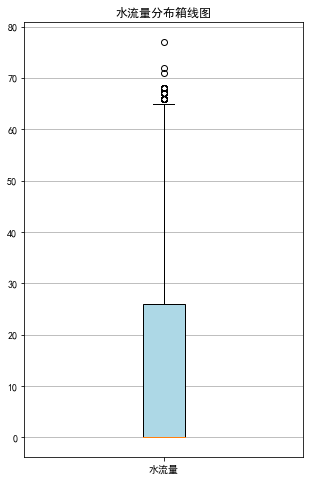

In [ ]:
# 绘制水流量分布箱型图
fig = plt.figure(figsize=(5 ,8))
plt.boxplot(water,
            patch_artist=True,  # 给箱子填充颜色
            labels = ['水流量'],  # 设置x轴标题
            boxprops = {'facecolor':'lightblue'})  # 设置填充颜色
plt.title('水流量分布箱线图')
# 显示y坐标轴的底线
plt.grid(axis='y')  # 添加水平网格线，方便看数值
plt.show()

告诉我们：水流量的具体数值分布  
可以看出：箱体贴近0 → 大量数据是0（无水流）

# 数据预处理

## 数据变换之连续属性离散化

### 用水停顿时间的分布情况

用水停顿事件间隔 = 一条水流量不为0的记录时间 至 下一条水流量不为0的记录时间

时间线（只看有水的时刻）：  

记录A：07:01:56（水流量=8）  ← 正在用水  
        ↓   
        （间隔了一段时间）  
记录B：07:38:16（水流量=8）  ← 又在用水  

记录B的时间(07:38:16) - 记录A的时间(07:01:56) = 36分20秒  
这个36分20秒就是两次用水之间的停顿时长。

这个指标有什么用？  

| 间隔长短 | 含义 |
| :--- | :--- |
| 很短（几秒） | 可能是同一次用水（比如洗澡中间搓澡） |
| 中等（几分钟） | 可能是不同事情（洗手→洗碗） |
| 很长（十几分钟） | 肯定是不同次用水 |

切分用水事件的核心：间隔 < 4分钟 → 算同一次用水；间隔 > 4分钟 → 算新的一次用水。

In [ ]:
# 将“发生时间”转换为 Datetime
data['发生时间'] = pd.to_datetime(data['发生时间'], format='%Y%m%d%H%M%S')   
data.head()

,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
0,R_00001,2021-10-19 06:39:17,关,关,关,无,30°C,0%,0,关,0分钟,50°C
1,R_00001,2021-10-19 07:01:54,关,关,关,无,30°C,0%,0,关,0分钟,50°C
2,R_00001,2021-10-19 07:01:56,关,关,关,无,30°C,0%,8,关,0分钟,50°C
3,R_00001,2021-10-19 07:12:30,关,关,关,无,30°C,0%,0,关,0分钟,50°C
4,R_00001,2021-10-19 07:12:36,关,关,关,无,29°C,0%,0,关,0分钟,50°C


In [ ]:
# 用于备份
# inputfile = './data/original_data.xlsx'  # 输入的数据文件路径

# data_test = pd.read_excel(inputfile)  # 读取数据
# data_test['发生时间'] = pd.to_datetime(data_test['发生时间'], format='%Y%m%d%H%M%S')   
# data_test.to_excel('./data/original_data_test.xlsx')

In [ ]:
 # 提取水流量不为0的数据
use_water = data[data['水流量'] != 0]
use_water

,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
2,R_00001,2021-10-19 07:01:56,关,关,关,无,30°C,0%,8,关,0分钟,50°C
56,R_00001,2021-10-19 07:38:16,关,关,关,无,30°C,0%,8,关,0分钟,50°C
381,R_00001,2021-10-19 09:46:38,关,关,关,无,29°C,0%,16,关,0分钟,50°C
382,R_00001,2021-10-19 09:46:40,关,关,关,无,29°C,0%,13,关,0分钟,50°C
384,R_00001,2021-10-19 09:47:15,关,关,关,有,29°C,0%,20,关,0分钟,50°C
...,...,...,...,...,...,...,...,...,...,...,...,...
18742,R_00001,2021-11-10 22:00:38,开,开,关,有,37°C,25%,26,关,17分钟,50°C
18743,R_00001,2021-11-10 22:00:42,开,开,关,有,37°C,25%,23,关,17分钟,50°C
18744,R_00001,2021-11-10 22:00:46,开,开,关,有,37°C,25%,25,关,17分钟,50°C
18798,R_00001,2021-11-10 22:19:43,开,关,开,无,50°C,50%,8,关,0分钟,50°C


In [ ]:
# diff()：计算相邻两条时间之间的差值（比如 10:00:03 - 10:00:01 = 2秒）
# [1:]：去掉第一个（因为第一条没有前一条可以减）
# / np.timedelta64(1, 'm')：把时间差值转换成分钟
use_diff = use_water['发生时间'].diff()[1:] / np.timedelta64(1, 'm')         
use_diff

56        36.333333
381      128.366667
382        0.033333
384        0.583333
404      123.033333
            ...    
18742      0.033333
18743      0.066667
18744      0.066667
18798     18.950000
18800     29.400000
Name: 发生时间, Length: 7695, dtype: float64

use_diff 存储的就是：每次用水结束到下一次用水开始之间的停顿时间。

In [ ]:
# 定义分箱的边界，每个区间左闭右开
# use_diff.max()：找出最长的停顿时间+1(左闭右开)
space = [0, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, use_diff.max()+1]  
labels = ['0~0.1', '0.1~0.2', '0.2~0.3', '0.3~0.5', '0.5~1', '1~2', '2~3', '3~4', '4~5', '5~6', '6~7', '7~8',
         '8~9', '9~10', '10~11', '11~12', '12~13', '13 以上']
# 分箱(左闭右开)，计数，按索引排序
time_table = pd.value_counts(pd.cut(use_diff, space, right=False, labels=labels)).sort_index()    
time_table.index.name = '频数'
time_table

频数
0~0.1      5576
0.1~0.2    1385
0.2~0.3     324
0.3~0.5     119
0.5~1        46
1~2          33
2~3          15
3~4          14
4~5           1
5~6           8
6~7           5
7~8           6
8~9           4
9~10          5
10~11         1
11~12         7
12~13         1
13 以上       134
Name: 发生时间, dtype: int64

核心发现：  
短停顿（<1分钟）：5576 + 1385 + 324 + 119 + 46 = 7450次  
长停顿（>13分钟）：134次  

关键结论：  
绝大多数停顿都很短（<1分钟）  
这些短停顿 → 属于同一次用水中间的自然停顿（洗澡搓澡、打沐浴露）  
长停顿 → 才是真正的两次不同用水之间的间隔

从结果看：  
3-4分钟：只有14次停顿   
4-5分钟：只有1次停顿  
这说明：超过3分钟的停顿已经很少了，用4分钟作为"切分点"是合理的。

### 绘制用水停顿时间帕累托图

Text(1.8,0.853267,'94.8074%')

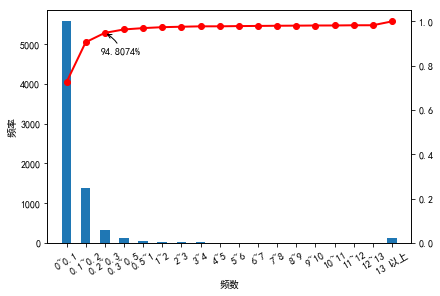

In [ ]:
plt.rcParams['figure.constrained_layout.use'] = True    # 自动调整图表布局，避免标签被遮挡
plt.rcParams['font.sans-serif'] = ['SimHei']    # 显示中文
ax = time_table.plot(kind='bar')  # 画柱状图，横坐标是区间，纵坐标是频数
ax.set_xlabel('区间')  # 横轴标题
ax.set_ylabel('频率')  # 纵轴标题
p = 1.0 * time_table.cumsum() / time_table.sum()
# time_table.cumsum()：计算累计频数（第一个区间+第二个区间+...）
# time_table.sum()：计算总频数
# p = ...：计算累计百分比（累计频数 ÷ 总频数）
ax2 = p.plot(color='r', secondary_y=True, style='-o', linewidth=2, rot=30)  
# 画累计百分比曲线
# color='r'：线条颜色为红色
# secondary_y=True：使用右侧的纵坐标轴（和柱状图的左侧轴分开）
# style='-o'：线条样式：实线+圆点
# linewidth=2：线条粗细为2
# rot=30：横坐标标签旋转30度
ax2.set_ylim((0, 1.05))  # 右侧Y轴范围：0% 到 105%
ax2.set_xlim(-1, 18)  # X轴范围：-1 到 18（留一点边距）
plt.annotate(format(p[2], '0.4%'), xy=(2, p[2]), xytext=(2*0.9, p[2]*0.9), 
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3, rad=.2'))    # 绘制文本与箭头
# plt.annotate(...)：在图上添加注释（文字+箭头）
# format(p[2], '0.4%')：把第3个区间的累计百分比格式化成百分比（如"85.00%"）
# xy=(2, p[2])：箭头指向的位置（第3个柱子的顶部）
# xytext=(2*0.9, p[2]*0.9)：文字放置的位置（向左下方偏移一点）
# arrowprops=...：箭头的样式

0-0.1分钟：5576次 → 占 72.5%  
0-0.2分钟：6961次 → 占 90.5%  
0-0.3分钟：7285次 → 占 94.8%  ← 这里  
含义：94.8%的停顿都在0.3分钟（18秒）以内

结论：用户的大部分停顿都极短（<18秒），4分钟的阈值足够安全，不会把一次洗澡切碎，也不会把两次洗澡合并。

## 数据规约之属性规约

In [ ]:
# 读取数据
data = pd.read_excel(inputfile) 
print('初始状态的数据形状为：', data.shape)

初始状态的数据形状为： (18840, 12)


In [ ]:
# 删除冗余属性
data.drop(['热水器编号','有无水流','节能模式','当前设置温度'],axis=1,inplace=True) 
data.shape

(18840, 8)

In [ ]:
# 保存规约的数据为water_heat.csv，不将 DataFrame 的行索引（行号）写入文件
data.to_csv('./data/water_heat.csv',index=False)
data.head()

,发生时间,开关机状态,加热中,保温中,实际温度,热水量,水流量,加热剩余时间
0,20211019063917,关,关,关,30°C,0%,0,0分钟
1,20211019070154,关,关,关,30°C,0%,0,0分钟
2,20211019070156,关,关,关,30°C,0%,8,0分钟
3,20211019071230,关,关,关,30°C,0%,0,0分钟
4,20211019071236,关,关,关,29°C,0%,0,0分钟


## 数据集成之合并数据

### 划分单次用水事件

把连续的数据流，切分成一个个独立的"用水事件"。

1）第一步：设定“切分”的标准

前面得到的结论：如果两次用水记录之间的间隔超过4分钟，就认为这是两次不同的用水事件（比如一次洗手和一次洗澡）。如果间隔小于4分钟，就认为它们属于同一次用水（比如洗澡中间搓沐浴露的停顿）。

In [ ]:
import pandas as pd
threshold=pd.Timedelta(minutes=4)#阈值为4分钟
threshold

Timedelta('0 days 00:04:00')

2）第二步：准备数据，只保留“有水”的记录

In [ ]:
# 读取和准备数据，将“发生时间”转换为 Datetime
data=pd.read_excel(inputfile)
data['发生时间']=pd.to_datetime(data['发生时间'],format='%Y%m%d%H%M%S')
#只要流水量大于0的记录
data=data[data['水流量']>0]
data.head(6)

,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
2,R_00001,2021-10-19 07:01:56,关,关,关,无,30°C,0%,8,关,0分钟,50°C
56,R_00001,2021-10-19 07:38:16,关,关,关,无,30°C,0%,8,关,0分钟,50°C
381,R_00001,2021-10-19 09:46:38,关,关,关,无,29°C,0%,16,关,0分钟,50°C
382,R_00001,2021-10-19 09:46:40,关,关,关,无,29°C,0%,13,关,0分钟,50°C
384,R_00001,2021-10-19 09:47:15,关,关,关,有,29°C,0%,20,关,0分钟,50°C
404,R_00001,2021-10-19 11:50:17,关,关,关,有,29°C,0%,22,关,0分钟,50°C


第381、382、384行之间时间很近（几秒到几十秒），很可能属于同一次用水（比如一次洗澡）。  
第56行和第381行之间隔了2个多小时，明显是不同次用水。    
所以我们要做的是：把时间上靠近的记录合并成一“事件”，时间上远离的切开。

3）第三步：找出“需要切开”的地方

d 的作用：标记"这里是一个新事件的开始"

In [ ]:
d=data['发生时间'].diff()>threshold 
# 作用：计算每一条记录和上一条记录的时间差，判断是否大于4分钟。
# 结果：得到一列 True/False。
# True → 该记录和上一条间隔 > 4分钟，应该从这里切一刀，作为新事件的开始。
# False → 间隔很短，继续归为同一次事件。
d.head(6)

2      False
56      True
381     True
382    False
384    False
404     True
Name: 发生时间, dtype: bool

In [ ]:
# 第一条记录没有“上一条”，所以强制设为 True，表示它是第一个事件的开始。
d.iloc[0] = True 
d.head(6)

2       True
56      True
381     True
382    False
384    False
404     True
Name: 发生时间, dtype: bool

| Python索引 | 发生时间 | 与上一条的时间差 | 是否>4分钟？ | d |
|------|----------|----------------|-------------|-----|
| 2    | 07:01:56 | —（没有上一条） | —           | True（强制设为开始） |
| 56   | 07:38:16 | 36分20秒       | ✅ 是       | True |
| 381  | 09:46:38 | 2小时8分22秒   | ✅ 是       | True |
| 382  | 09:46:40 | 2秒            | ❌ 否       | False |
| 384  | 09:47:15 | 35秒           | ❌ 否       | False |
| 404  | 11:50:17 | 2小时3分2秒    | ✅ 是       | True |

d 列的含义：  
True = 这里是一个新事件的开头  
False = 跟上一条属于同一个事件

从 d 列可以看出：  
事件1：从行2开始  
事件2：从行56开始  
事件3：从行381开始（包括381、382、384）  
事件4：从行404开始

| Python索引 | 行号 | d（开始标志） | 含义 |
|------------|------|---------------|------|
| 2 | 第3行 | True | 事件1开始 |
| 56 | 第57行 | True | 事件2开始 |
| 381 | 第382行 | True | 事件3开始 |
| 404 | 第405行 | True | 事件4开始 |

4）第四步：确定每个事件的“结束位置”

一个事件的结束位置 = 下一个事件的开始位置的前一行有水数据

In [ ]:
# 去掉 d 的第一个值，得到从第二条记录开始的标志。
h=d.iloc[1:] 
h.head()

56      True
381     True
382    False
384    False
404     True
Name: 发生时间, dtype: bool

为什么要去掉第一行？因为一个事件的结束位置，其实是下一个事件的开始位置的前一行。

举个例子：  
事件1从行2开始，事件2从行56开始  
那么事件1的结束位置就是行56的上一行有水数据，也就是行2  
所以我们把 d 往后错一位，就能得到“结束标志”。

In [ ]:
# 在末尾手动添加一个 True，表示 最后一条记录一定是某个事件的结束。
h = pd.concat([h,pd.Series(True)])   
h.tail()

18743    False
18744    False
18798     True
18800     True
0         True
dtype: bool

| Python索引 | d（开始） | h（结束标志） | 含义 |
|------|-----------|---------------|------|
| 2 | True | （被删掉） | 不管它 |
| 56 | True | True | 事件1在行56之前结束（即行2结束） |
| 381 | True | True | 事件2在行381之前结束（即行56结束） |
| 382 | False | False | 不是结束 |
| 384 | False | False | 不是结束 |
| 404 | True | True | 事件3在行404之前结束（即行384结束） |
| （末尾） | — | True（手动加） | 事件4在这里结束（行404结束） |

5）第五步：给每个事件编号，并记录起止位置

In [ ]:
sj = pd.DataFrame(np.arange(1,sum(d)+1),columns = ["事件序号"]) 
# sum(d)：统计 d 中有多少个 True → 就是事件总数
# np.arange(1, sum(d)+1) = 生成 1, 2, 3, ... 作为事件序号
sj

,事件序号
0,1
1,2
2,3
3,4
4,5
...,...
168,169
169,170
170,171
171,172


In [ ]:
d == 1

2         True
56        True
381       True
382      False
384      False
         ...  
18742    False
18743    False
18744    False
18798     True
18800     True
Name: 发生时间, Length: 7696, dtype: bool

In [ ]:
data

,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
2,R_00001,2021-10-19 07:01:56,关,关,关,无,30°C,0%,8,关,0分钟,50°C
56,R_00001,2021-10-19 07:38:16,关,关,关,无,30°C,0%,8,关,0分钟,50°C
381,R_00001,2021-10-19 09:46:38,关,关,关,无,29°C,0%,16,关,0分钟,50°C
382,R_00001,2021-10-19 09:46:40,关,关,关,无,29°C,0%,13,关,0分钟,50°C
384,R_00001,2021-10-19 09:47:15,关,关,关,有,29°C,0%,20,关,0分钟,50°C
...,...,...,...,...,...,...,...,...,...,...,...,...
18742,R_00001,2021-11-10 22:00:38,开,开,关,有,37°C,25%,26,关,17分钟,50°C
18743,R_00001,2021-11-10 22:00:42,开,开,关,有,37°C,25%,23,关,17分钟,50°C
18744,R_00001,2021-11-10 22:00:46,开,开,关,有,37°C,25%,25,关,17分钟,50°C
18798,R_00001,2021-11-10 22:19:43,开,关,开,无,50°C,50%,8,关,0分钟,50°C


In [ ]:
data.index[d == 1]

Int64Index([    2,    56,   381,   404,   407,   410,   612,   659,   772,
             1025,
            ...
            17896, 17997, 18198, 18371, 18405, 18465, 18534, 18669, 18798,
            18800],
           dtype='int64', length=173)

In [ ]:
sj["事件起始编号"] = data.index[d == 1]+1 
# d == 1 找到所有 True 的位置（行2、56、381、404...）。
# +1 是因为 Python 从0开始计数，但我们要显示为 Excel 行号（从1开始）。
sj

,事件序号,事件起始编号
0,1,3
1,2,57
2,3,382
3,4,405
4,5,408
...,...,...
168,169,18466
169,170,18535
170,171,18670
171,172,18799


In [ ]:
h == 1

56        True
381       True
382      False
384      False
404       True
         ...  
18743    False
18744    False
18798     True
18800     True
0         True
Length: 7696, dtype: bool

In [ ]:
data

,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
2,R_00001,2021-10-19 07:01:56,关,关,关,无,30°C,0%,8,关,0分钟,50°C
56,R_00001,2021-10-19 07:38:16,关,关,关,无,30°C,0%,8,关,0分钟,50°C
381,R_00001,2021-10-19 09:46:38,关,关,关,无,29°C,0%,16,关,0分钟,50°C
382,R_00001,2021-10-19 09:46:40,关,关,关,无,29°C,0%,13,关,0分钟,50°C
384,R_00001,2021-10-19 09:47:15,关,关,关,有,29°C,0%,20,关,0分钟,50°C
...,...,...,...,...,...,...,...,...,...,...,...,...
18742,R_00001,2021-11-10 22:00:38,开,开,关,有,37°C,25%,26,关,17分钟,50°C
18743,R_00001,2021-11-10 22:00:42,开,开,关,有,37°C,25%,23,关,17分钟,50°C
18744,R_00001,2021-11-10 22:00:46,开,开,关,有,37°C,25%,25,关,17分钟,50°C
18798,R_00001,2021-11-10 22:19:43,开,关,开,无,50°C,50%,8,关,0分钟,50°C


In [ ]:
data.index[h == 1]

Int64Index([    2,    56,   384,   404,   407,   593,   618,   765,   922,
             1134,
            ...
            17896, 18141, 18324, 18371, 18452, 18470, 18652, 18744, 18798,
            18800],
           dtype='int64', length=173)

In [ ]:
sj["事件终止编号"] = data.index[h == 1]+1  
# h == 1 找到所有 True 的位置（行56、381、404...）。
# 同样 +1。
sj

,事件序号,事件起始编号,事件终止编号
0,1,3,3
1,2,57,57
2,3,382,385
3,4,405,405
4,5,408,408
...,...,...,...
168,169,18466,18471
169,170,18535,18653
170,171,18670,18745
171,172,18799,18799


| 事件序号 | 事件起始编号（行号） | 事件终止编号（行号） | 包含的原始行 |
|----------|----------------------|----------------------|--------------|
| 1 | 3（行2） | 3（行2） | 行2 |
| 2 | 57（行56） | 57（行56） | 行56 |
| 3 | 382（行381） | 385（行384） | 381、382、384 |
| 4 | 405（行404） | 405（行404） | 行404 |

In [ ]:
# 保存结果到outputfile
data.to_excel(outputfile)

## 数据变换之属性构造

### 构建用水时长与频率属性

目标：对每个用水事件，计算出它的 特征（时长、频率、水量等），为后面的建模做准备。  
通俗理解：就像你要分析一个人的洗澡习惯，你不能只看“他几点开的水”，你要算出“他洗了多久”、“中间停了几次”、“平均每次停多久”这些 有意义的指标。

1）第1步：读取数据

In [ ]:
# 读取热水器使用数据记录
data = pd.read_excel('./data/water_hearter.xlsx') 
data["发生时间"] = pd.to_datetime(data["发生时间"],format = "%Y%m%d%H%M%S") 

# 读取用水事件记录
sj = pd.read_csv('./data/sj.csv')

# 转换时间格式
timeDel = pd.Timedelta("1 sec")  # 定义一个“1秒”的时间间隔，后面用来微调时间。

2）第2步：计算每个事件的开始时间和结束时间

In [ ]:
data.iloc[sj["事件起始编号"]-1,0].values

array(['2021-10-19T07:01:56.000000000', '2021-10-19T07:38:16.000000000',
       '2021-10-19T09:46:38.000000000', '2021-10-19T11:50:17.000000000',
       '2021-10-19T13:56:21.000000000', '2021-10-19T15:34:39.000000000',
       '2021-10-19T15:55:15.000000000', '2021-10-19T17:23:21.000000000',
       '2021-10-19T17:46:21.000000000', '2021-10-19T21:32:45.000000000',
       '2021-10-19T21:47:05.000000000', '2021-10-19T21:54:30.000000000',
       '2021-10-20T06:59:33.000000000', '2021-10-20T07:22:54.000000000',
       '2021-10-20T13:33:54.000000000', '2021-10-20T19:03:41.000000000',
       '2021-10-20T19:13:45.000000000', '2021-10-20T19:47:59.000000000',
       '2021-10-20T20:18:11.000000000', '2021-10-20T21:46:22.000000000',
       '2021-10-20T23:02:13.000000000', '2021-10-21T06:43:37.000000000',
       '2021-10-21T07:49:07.000000000', '2021-10-21T16:04:18.000000000',
       '2021-10-21T16:23:07.000000000', '2021-10-21T17:37:54.000000000',
       '2021-10-21T18:37:57.000000000', '2021-10-21

In [ ]:
sj["事件开始时间"] = data.iloc[sj["事件起始编号"]-1,0].values- timeDel
sj.head()

,事件序号,事件起始编号,事件结束编号,事件开始时间
0,1,3,3,2021-10-19 07:01:55
1,2,57,57,2021-10-19 07:38:15
2,3,382,385,2021-10-19 09:46:37
3,4,405,405,2021-10-19 11:50:16
4,5,408,408,2021-10-19 13:56:20


逐层拆解：  
sj["事件起始编号"]：事件开始的行（如第3行、第57行）  
-1：因为 Python 索引从0开始，行号3 → 索引2，所以要减1  
data.iloc[..., 0]：到 data 里取这一行的第0列（即“发生时间”）  
.values：取出具体的时间值  
-timeDel：把时间往前推1秒  
通俗理解：事件从第3行开始，那它的开始时间就是第3行的时间再往前1秒。为什么要往前1秒？是为了把 "刚好在边界" 的情况也包含进来。

In [ ]:
sj["事件结束时间"] = data.iloc[sj["事件结束编号"]-1, 0].values + timeDel
sj.head()

,事件序号,事件起始编号,事件结束编号,事件开始时间,事件结束时间
0,1,3,3,2021-10-19 07:01:55,2021-10-19 07:01:57
1,2,57,57,2021-10-19 07:38:15,2021-10-19 07:38:17
2,3,382,385,2021-10-19 09:46:37,2021-10-19 09:47:16
3,4,405,405,2021-10-19 11:50:16,2021-10-19 11:50:18
4,5,408,408,2021-10-19 13:56:20,2021-10-19 13:56:22


作用：计算每个用水事件的 结束时间  
通俗理解：和上面相反，事件结束时间是最后一条记录的时间再往后推1秒。

3）第3步：计算“洗浴时间点”

In [ ]:
sj['洗浴时间点'] = [i.hour for i in sj["事件开始时间"]]
sj.head()

,事件序号,事件起始编号,事件结束编号,事件开始时间,事件结束时间,洗浴时间点
0,1,3,3,2021-10-19 07:01:55,2021-10-19 07:01:57,7
1,2,57,57,2021-10-19 07:38:15,2021-10-19 07:38:17,7
2,3,382,385,2021-10-19 09:46:37,2021-10-19 09:47:16,9
3,4,405,405,2021-10-19 11:50:16,2021-10-19 11:50:18,11
4,5,408,408,2021-10-19 13:56:20,2021-10-19 13:56:22,13


作用：从“事件开始时间”里提取 小时数（0~23）  
通俗理解：事件开始时间是 2021-10-19 07:01:56，那 i.hour = 7，表示这个事件发生在早上7点。  
有什么用：可以用来分析用户习惯，比如是早上洗澡还是晚上洗澡。

4）第4步：计算“总用水时长”

In [ ]:
tmp1 = sj["事件结束时间"] - sj["事件开始时间"]
sj["总用水时长"] = np.int64(tmp1)/1000000000 
sj.head()

,事件序号,事件起始编号,事件结束编号,事件开始时间,事件结束时间,洗浴时间点,总用水时长
0,1,3,3,2021-10-19 07:01:55,2021-10-19 07:01:57,7,2.0
1,2,57,57,2021-10-19 07:38:15,2021-10-19 07:38:17,7,2.0
2,3,382,385,2021-10-19 09:46:37,2021-10-19 09:47:16,9,39.0
3,4,405,405,2021-10-19 11:50:16,2021-10-19 11:50:18,11,2.0
4,5,408,408,2021-10-19 13:56:20,2021-10-19 13:56:22,13,2.0


作用：计算每个事件的 总时长（从开始到结束）  
逐层拆解：  
事件结束时间 - 事件开始时间：得到一个时间差（比如 5分钟30秒）  
np.int64(tmp1)：把时间差转成 纳秒数（1秒 = 10亿纳秒）  
/ 1000000000：纳秒数 ÷ 10亿 = 秒数  
通俗理解：一个事件从开始到结束一共持续了多少秒（包括了中间的停顿时间）。

In [ ]:
tmp1 = sj["事件结束时间"] - sj["事件开始时间"]
sj["总用水时长"] = np.int64(tmp1)/1000000000 
sj.head()

,事件序号,事件起始编号,事件结束编号,事件开始时间,事件结束时间,洗浴时间点,总用水时长
0,1,3,3,2021-10-19 07:01:55,2021-10-19 07:01:57,7,2.0
1,2,57,57,2021-10-19 07:38:15,2021-10-19 07:38:17,7,2.0
2,3,382,385,2021-10-19 09:46:37,2021-10-19 09:47:16,9,39.0
3,4,405,405,2021-10-19 11:50:16,2021-10-19 11:50:18,11,2.0
4,5,408,408,2021-10-19 13:56:20,2021-10-19 13:56:22,13,2.0
